In [1]:
import pandas as pd
import geopandas as gpd
import transbigdata as tbd
# ensure tbd version is above 0.5.0
tbd.__version__

'0.5.3'

# 轨迹数据质量

In [2]:
# Read the data
# 按照每辆车的时间顺序排列
data = pd.read_csv(r'C:\Users\Mth13\Desktop\毕设code\gps_1101.csv')
# data = data.groupby('vid_md5', group_keys=False).apply(lambda x: x.sort_values('标准时间'))
# data['标准时间'] = pd.to_datetime(data['标准时间'])

# # 保存时添加编码参数
# data.to_csv(r'C:\Users\Mth13\Desktop\毕设code\gps_1101.csv', 
#            index=False, 
#            encoding='utf_8_sig')  # 或使用 'gb18030'

data

,vid_md5,脱敏车牌号,车牌颜色,sim卡号,Lng,Lat,标准时间,系统时间,省名称,市名称,...,右转向灯信号,远光灯信号,近光灯信号,方向,终端状态,车辆状态,报警标志,ACC状态,gps时间,与正北方向夹角
0,0000197cc82d65668a33e64f060d0e49,陕AW***0,黄色,6.473314e+10,109.078582,34.428697,2021-11-01 00:00:00,2021/11/1 0:00,陕西省,西安市,...,0.0,0.0,0.0,正北,北斗定位,熄火,^,ACC关,2021/11/1 0:00,0.0
1,0000197cc82d65668a33e64f060d0e49,陕AW***0,黄色,6.473314e+10,109.078582,34.428697,2021-11-01 00:05:00,2021/11/1 0:05,陕西省,西安市,...,0.0,0.0,0.0,正北,北斗定位,熄火,^,ACC关,2021/11/1 0:05,0.0
2,0000197cc82d65668a33e64f060d0e49,陕AW***0,黄色,6.473314e+10,109.078582,34.428697,2021-11-01 00:10:00,2021/11/1 0:10,陕西省,西安市,...,0.0,0.0,0.0,正北,北斗定位,熄火,^,ACC关,2021/11/1 0:10,0.0
3,0000197cc82d65668a33e64f060d0e49,陕AW***0,黄色,6.473314e+10,109.078582,34.428697,2021-11-01 00:15:00,2021/11/1 0:15,陕西省,西安市,...,0.0,0.0,0.0,正北,北斗定位,熄火,^,ACC关,2021/11/1 0:15,0.0
4,0000197cc82d65668a33e64f060d0e49,陕AW***0,黄色,6.473314e+10,109.078582,34.428697,2021-11-01 00:20:00,2021/11/1 0:20,陕西省,西安市,...,0.0,0.0,0.0,正北,北斗定位,熄火,^,ACC关,2021/11/1 0:20,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
943996,0730e5b083aef2357495aeb2070507c0,冀JZ***5,黄色,6.425432e+10,108.740410,34.055635,2021-11-01 20:30:00,2021/11/1 20:30,陕西省,西安市,...,0.0,1.0,0.0,东北,北斗定位,点火,^,ACC开,2021/11/1 20:30,41.0
943997,0730e5b083aef2357495aeb2070507c0,冀JZ***5,黄色,6.425432e+10,108.740410,34.055635,2021-11-01 20:31:00,2021/11/1 20:31,陕西省,西安市,...,0.0,1.0,0.0,东北,北斗定位,点火,^,ACC开,2021/11/1 20:31,41.0
943998,0730e5b083aef2357495aeb2070507c0,冀JZ***5,黄色,6.425432e+10,108.740410,34.055635,2021-11-01 20:31:00,2021/11/1 20:31,陕西省,西安市,...,0.0,0.0,1.0,东北,北斗定位,点火,^,ACC开,2021/11/1 20:31,41.0
943999,0730e5b083aef2357495aeb2070507c0,冀JZ***5,黄色,6.425432e+10,108.740410,34.055635,2021-11-01 20:32:00,2021/11/1 20:32,陕西省,西安市,...,0.0,0.0,1.0,东北,北斗定位,行驶,^,ACC开,2021/11/1 20:32,41.0


In [3]:
# 在保存CSV前添加验证代码
# 按车辆分组检查时间是否单调递增
check_result = data.groupby('vid_md5')['标准时间'].apply(lambda x: x.is_monotonic_increasing)
print("未正确排序的车辆数量:", (~check_result).sum())

未正确排序的车辆数量: 0


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 944001 entries, 0 to 944000
Data columns (total 31 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   vid_md5  944001 non-null  object 
 1   脱敏车牌号    944001 non-null  object 
 2   车牌颜色     944001 non-null  object 
 3   sim卡号    944001 non-null  float64
 4   Lng      944001 non-null  float64
 5   Lat      944001 non-null  float64
 6   标准时间     944001 non-null  object 
 7   系统时间     944001 non-null  object 
 8   省名称      944001 non-null  object 
 9   市名称      944001 non-null  object 
 10  区县名称     944001 non-null  object 
 11  gps速度    944001 non-null  float64
 12  道路ID序列   675381 non-null  object 
 13  里程表里程    919138 non-null  float64
 14  海拔       944001 non-null  int64  
 15  vss速度    891537 non-null  float64
 16  空档信号     895806 non-null  float64
 17  喇叭信号     895806 non-null  float64
 18  倒挡信号     895806 non-null  float64
 19  制动信号     895806 non-null  float64
 20  左转向灯信号   895806 non-null  

Amount of data
-----------------
Total number of data items:  944001
Total number of individuals:  1468
Data volume of individuals(Mean):  643.0525
Data volume of individuals(Upper quartile):  784.0
Data volume of individuals(Median):  299.0
Data volume of individuals(Lower quartile):  121.0

Data time period
-----------------
Start time:  2021-11-01 00:00:00
End time:  2021-11-01 23:59:00

Sampling interval
-----------------
Mean:  62.5051 s
Upper quartile:  60.0 s
Median:  0.0 s
Lower quartile:  0.0 s


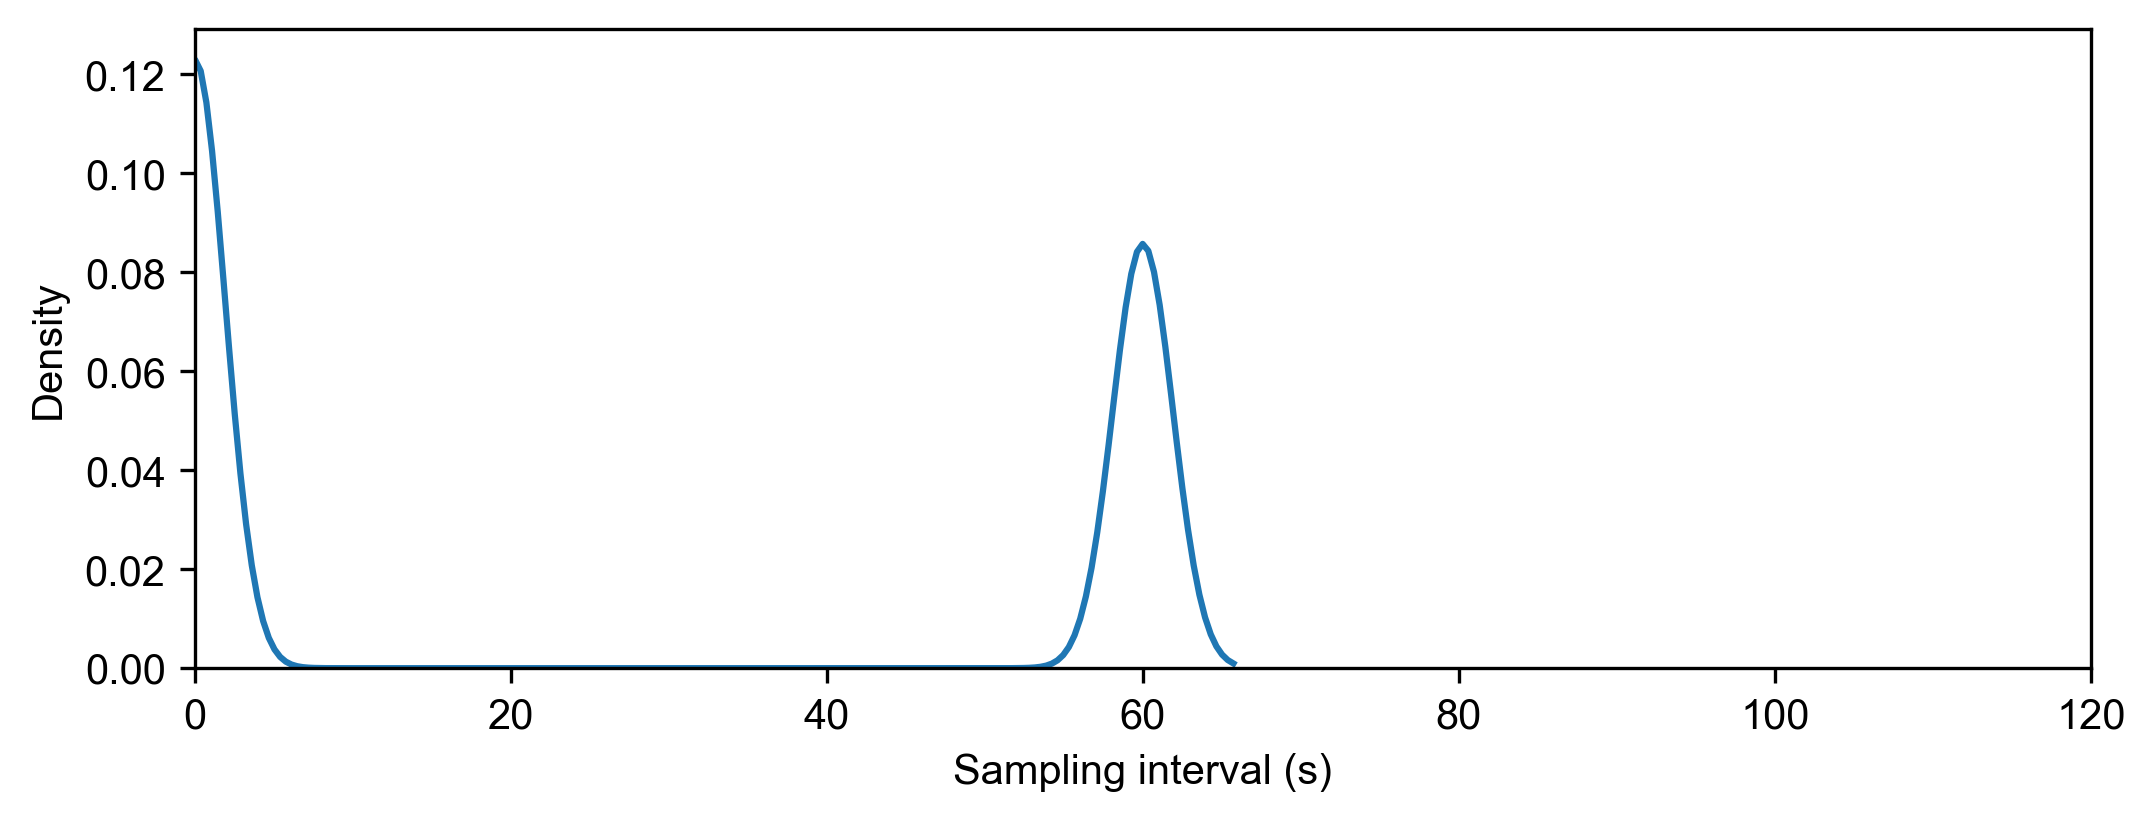

In [5]:
# Generate data quality report
tbd.data_summary(data, 
                col=['vid_md5', '标准时间'], 
                show_sample_duration=True,
                ) 
# tbd.sample_duration(data, col=['vid_md5', '标准时间'])

# 冗余消除

In [ ]:
# data volume before Redundancy Elimination
len(data)

In [ ]:
# Data redundancy removal to reduce data size and improve computational efficiency in subsequent steps
data = tbd.traj_clean_redundant(
    data,
    col=['vid_md5', '标准时间', 'Lng', 'Lat', 'gps速度']  # Apart from vehicle ID, time, longitude, and latitude, consider whether the speed field has redundancy
)
len(data)


In [65]:
# 保存时添加编码参数
data.to_csv(r'C:\Users\Mth13\Desktop\毕设code\gps_clean_redundant.csv', 
           index=False, 
           encoding='utf_8_sig')  # 或使用 'gb18030'

In [ ]:
data.info()

In [ ]:
# Generate data quality report
tbd.data_summary(data, 
                col=['vid_md5', '标准时间'], 
                show_sample_duration=True,
                ) 
# tbd.sample_duration(data, col=['vid_md5', '标准时间'])

In [ ]:
# 在保存CSV前添加验证代码
# 按车辆分组检查时间是否单调递增
check_result = data.groupby('vid_md5')['标准时间'].apply(lambda x: x.is_monotonic_increasing)
print("未正确排序的车辆数量:", (~check_result).sum())

# 特征计算

# 漂移清理

In [ ]:
# Read the research area range
xi_an = gpd.read_file('西安市道路数据/610100边界.geojson')
xi_an

In [ ]:
xi_an.plot()

In [ ]:
# Data drift removal
# Removing data outside the study area
data = tbd.clean_outofshape(data, xi_an, col=['Lng', 'Lat'], accuracy=100)
len(data)

In [ ]:
# Drift cleaning within the study area using speed, distance, and angle as criteria
data = tbd.traj_clean_drift(
    data,  # Trajectory data, can include data for multiple vehicles, distinguished by ID
    col=['vid_md5', '标准时间', 'Lng', 'Lat'],  # Column names of the trajectory data
    speedlimit=120,  # Speed threshold in km/h, set to None to skip speed-based filtering
    dislimit=4000,  # Distance threshold in meters, set to None to skip distance-based filtering
    anglelimit=30)  # Angle threshold in degrees, set to None to skip angle-based filtering
len(data)

In [ ]:
data

# 轨迹平滑处理

In [14]:
import numpy as np
from pykalman import KalmanFilter
def Kalman_traj_smooth(data, process_noise_std, measurement_noise_std):
    '''
    使用卡尔曼滤波器对轨迹数据进行平滑处理
    
    参数
    ----
    data : DataFrame
        轨迹数据，包含time、lon、lat三列
    process_noise_std : float or list
        过程噪声标准差，如果是list，则认为是过程噪声协方差矩阵的对角线元素
    measurement_noise_std : float or list
        观测噪声标准差，如果是list，则认为是观测噪声协方差矩阵的对角线元素

    返回
    ----
    data : DataFrame
        平滑后的轨迹数据
    '''
    # 拷贝数据，避免修改原始数据
    data = data.copy()
    # 轨迹数据转换为numpy数组
    observations = data[['Lng', 'Lat']].values
    timestamps = data['标准时间']
    # F-状态转移矩阵
    transition_matrix = np.array([[1, 0, 1, 0],
                                  [0, 1, 0, 1],
                                  [0, 0, 1, 0],
                                  [0, 0, 0, 1]])
    # H-观测矩阵
    observation_matrix = np.array([[1, 0, 0, 0],
                                   [0, 1, 0, 0]])
    # R-观测噪声协方差矩阵
    # 如果measurement_noise_std是list，则认为是观测噪声协方差矩阵的对角线元素
    if isinstance(measurement_noise_std, list):
        observation_covariance = np.diag(measurement_noise_std)**2
    else:
        observation_covariance = np.eye(2) * measurement_noise_std**2
    # Q-过程噪声协方差矩阵
    # 如果process_noise_std是list，则认为是过程噪声协方差矩阵的对角线元素
    if isinstance(process_noise_std, list):
        transition_covariance = np.diag(process_noise_std)**2
    else:
        transition_covariance = np.eye(4) * process_noise_std**2
    # 初始状态
    initial_state_mean = [observations[0, 0], observations[0, 1], 0, 0]
    # 初始状态协方差矩阵
    initial_state_covariance = np.eye(4) * 1
    # 初始化卡尔曼滤波器
    kf = KalmanFilter(
        transition_matrices=transition_matrix,
        observation_matrices=observation_matrix,
        initial_state_mean=initial_state_mean,
        initial_state_covariance=initial_state_covariance,
        observation_covariance=observation_covariance,
        transition_covariance=transition_covariance
    )
    # 使用卡尔曼滤波器进行平滑处理
    # 先创建变量存储平滑后的状态
    smoothed_states = np.zeros((len(observations), 4))
    # 将初始状态存储到平滑后的状态中
    smoothed_states[0, :] = initial_state_mean
    # 从第二个状态开始，进行循环迭代
    current_state = initial_state_mean
    current_covariance = initial_state_covariance
    for i in range(1, len(observations)):
        # 计算时间间隔
        dt = (timestamps.iloc[i] - timestamps.iloc[i - 1]).total_seconds()  
        # 更新状态转移矩阵
        kf.transition_matrices = np.array([[1, 0, dt, 0],
                                           [0, 1, 0, dt],
                                           [0, 0, 1, 0],
                                           [0, 0, 0, 1]])
        # 根据当前状态的预测情况与观测结果进行状态估计
        current_state, current_covariance = kf.filter_update(
            current_state, current_covariance, observations[i]
        )
        # 将平滑后的状态存储到变量中
        smoothed_states[i, :] = current_state 
    # 将平滑后的数据结果添加到原始数据中
    data['Lng'] = smoothed_states[:, 0]
    data['Lat'] = smoothed_states[:, 1]
    return data


In [15]:
traj_smoothed = Kalman_traj_smooth(data, 
                                   process_noise_std = 0.01, 
                                   measurement_noise_std = 1)

In [ ]:
# 保存结果
traj_smoothed.to_csv('traj_smoothed.csv', index=False)
print("轨迹平滑处理完成，结果已保存到 traj_smoothed.csv")
traj_smoothed

In [ ]:
import matplotlib.pyplot as plt
# 显示中文
plt.rcParams['font.sans-serif']=['SimHei']
plt.rcParams['axes.unicode_minus'] = False
fig = plt.figure(1,(5,5),dpi=300)
ax = plt.subplot(111)

vehicle_id = '0001699af44d2a4bc5858c3111f250be'  # 以这辆车为例子
data_sample_origin = data[data['vid_md5'] == vehicle_id]
data_sample_smoothed = traj_smoothed[traj_smoothed['vid_md5'] == vehicle_id]  # 筛选特定车辆的数据


#绘制原始轨迹与平滑后的轨迹
plt.plot(data_sample_origin['Lng'], data_sample_origin['Lat'],label = '原始轨迹')
plt.plot(data_sample_smoothed['Lng'], data_sample_smoothed['Lat'],label = '平滑后轨迹')
plt.legend()
plt.show()

# 停止和行程提取

In [ ]:
# Define the grid parameters
# 读取西安的行政区划
xian = gpd.read_file('西安市道路数据/610100边界.geojson')
bounds = xian
params = tbd.area_to_params(bounds,accuracy = 100)
params

In [ ]:
data = pd.read_csv(r'traj_smoothed.csv')
data['标准时间'] = pd.to_datetime(data['标准时间'])
# Identify stay and move
stay, move = tbd.traj_stay_move(data, params, col=['vid_md5', '标准时间', 'Lng', 'Lat'], activitytime=1800)
len(stay), len(move)

In [ ]:
stay

In [ ]:
move

# 轨迹切片

In [ ]:
# Extract trajectory points during parking
stay_points = tbd.traj_slice(data, stay, traj_col=['vid_md5', '标准时间'], slice_col=[
                             'vid_md5', 'stime', 'etime', 'stayid'])
stay_points

In [ ]:
# Extract trajectory points during travel
move_points = tbd.traj_slice(data, move, traj_col=['vid_md5', '标准时间'], slice_col=[
                             'vid_md5', 'stime', 'etime', 'moveid'])

# 按车辆分组并按标准时间排序
move_points_sorted = move_points.groupby('vid_md5', group_keys=False).apply(lambda x: x.sort_values('标准时间'))
move_points_sorted['标准时间'] = pd.to_datetime(data['标准时间'])

# 计算前向时间差（当前点与下一个点的时间差）
move_points_sorted['前向时间差'] = move_points_sorted.groupby('vid_md5')['标准时间'].diff(-1).abs()

# 计算后向时间差（当前点与前一个点的时间差）
move_points_sorted['后向时间差'] = move_points_sorted.groupby('vid_md5')['标准时间'].diff()

# 筛选条件：前向或后向时间差均不超过5分钟-

move_points_filtered = move_points_sorted[
    (
        (move_points_sorted['前向时间差'].isna()) |  # 最后一组点的前向时间差为NaN
        (move_points_sorted['前向时间差'] <= pd.Timedelta(minutes=5))
    ) & (
        (move_points_sorted['后向时间差'].isna()) |  # 第一组点的后向时间差为NaN
        (move_points_sorted['后向时间差'] <= pd.Timedelta(minutes=5))
    )
]

# 删除临时列
move_points_filtered = move_points_filtered.drop(columns=['前向时间差', '后向时间差'])

# 按车辆分组并按标准时间排序
move_points_sorted = move_points_sorted.groupby('vid_md5', group_keys=False).apply(lambda x: x.sort_values('标准时间'))
move_points_sorted['标准时间'] = pd.to_datetime(data['标准时间'])
# 保存为 CSV 文件
move_points_filtered.to_csv('filtered_move_points.csv', index=False, encoding='utf-8-sig')

print("数据已保存为 filtered_move_points.csv")

move_points_filtered

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import font_manager

# 设置中文显示（Windows系统）
plt.rcParams['font.sans-serif'] = ['SimHei']  # 使用黑体字体
plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题

# 计算时间间隔（单位：秒）
move_points_filtered['时间间隔'] = move_points_filtered.groupby('vid_md5')['标准时间'].diff().dt.total_seconds()
time_diffs = move_points_filtered['时间间隔'].dropna()

# 绘制直方图，纵坐标为概率
plt.figure(figsize=(10, 6))
sns.histplot(data=time_diffs[time_diffs <= 600], 
             bins=30, 
             stat='probability',  # 纵坐标为概率值（0-1）
             color='blue', 
             label='采样间隔概率分布（0-600秒）')
plt.title('采样间隔概率分布图（0-600秒）')
plt.xlabel('时间间隔（秒）')
plt.ylabel('概率')
plt.xticks(range(0, 600, 60))  # 设置横坐标刻度，从0到900秒，以60秒为间隔
plt.grid(True)
plt.legend()
plt.show()

# 轨迹增密化

In [25]:
# define a function to plot the trajectory
def plot_traj(traj):
    import folium
    # 1. Create a map with the center at the average coordinates of the trajectory
    m = folium.Map(location=[traj['Lat'].mean(), traj['Lng'].mean()],  # Map center
                zoom_start=14,  # Map zoom level
                tiles='cartodbpositron')  # Map style
    # 2. Add the trajectory
    folium.PolyLine(
        traj[['Lat', 'Lng']].values.tolist(),  # Trajectory coordinates
        color='red',  # Trajectory color
        weight=2.5,  # Trajectory width
        opacity=1).add_to(m)  # Trajectory opacity, add to the map after creating the trajectory
    # 3. Add trajectory points
    for i in range(len(traj)):
        folium.CircleMarker(
            location=[traj['Lat'].iloc[i], traj['Lng'].iloc[i]],  # Trajectory point coordinates
            radius=3,  # Trajectory point radius
            color='red',  # Trajectory point color
        ).add_to(m)  # Fill opacity, add to the map after creating the trajectory point
    # 4. Add start and end markers
    folium.Marker([traj['Lat'].iloc[0], traj['Lng'].iloc[0]],  # Start point coordinates
                popup='Start',  # Start marker label
                icon=folium.Icon(color='green')).add_to(m)  # Start marker color
    folium.Marker([traj['Lat'].iloc[-1], traj['Lng'].iloc[-1]],
                popup='End',
                icon=folium.Icon(color='red')).add_to(m)
    # 5. Display the map, directly in Jupyter Notebook
    return m

In [ ]:
moveid = "0003c079563b1156252128ec84c06c37"
# Original trajectory
traj = move_points_filtered[move_points_filtered['vid_md5']==moveid]
plot_traj(traj)